# Week 4: Model Evaluation — Confusion Matrix & Classification Report
**Author:** Om Gadekar 
**Date:** 2026-05-04  
**Task:** Evaluate the Random Forest department classifier using confusion matrix and classification report

In [18]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [19]:
# Load the saved model and vectorizer
vectorizer = joblib.load(r"D:\tfidf_vectorizer.pkl")
model      = joblib.load(r"D:\rf_department_model.pkl")
encoder    = joblib.load(r"D:\sentiment_label_encoder.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [20]:
# Load original dataset
df = pd.read_csv(r"C:\Users\gadek\citizen-grievance-nlp/notebook/cleaned_311_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (300698, 55)

Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough', 'School Name', 'School Number', 'School Region', 'School Code', 'School Phone Number', 'School Address', 'School City', 'School State', 'School Zip', 'School Not Found', 'School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Garage Lot Name', 'Ferry Direction', 'Ferry Terminal Name', 'Latitude', 'Longitude', 'Locati

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location,cleaned_text,token_count
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)",loud musicparty,2
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)",access,1
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)",access,1


## Preparing Test Data
We use the same 80/20 train-test split that was used during model training.
Setting random_state=42 ensures we get the exact same split.

In [21]:
# ── Cell 6 ── Prepare features using department mapping ──────────

# Map Complaint Type to department labels (same mapping used during training)
DEPT_MAP = {
    'Roads & Transport':  ['Blocked Driveway', 'Illegal Parking', 'Traffic',
                           'Derelict Vehicle', 'Bike/Roller/Skate Chronic', 'Squeegee'],
    'Sanitation':         ['Graffiti', 'Posting Advertisement', 'Vending',
                           'Urinating in Public', 'Drinking', 'Panhandling'],
    'Parks & Recreation': ['Noise - Park', 'Animal in a Park', 'Animal Abuse'],
    'Health & Sanitation':['Noise - Commercial', 'Noise - Street/Sidewalk',
                           'Noise - Vehicle', 'Noise - House of Worship',
                           'Homeless Encampment', 'Disorderly Youth', 'Illegal Fireworks'],
}

def map_dept(complaint_type):
    for dept, types in DEPT_MAP.items():
        if complaint_type in types:
            return dept
    return None

# Apply mapping
df['department'] = df['Complaint Type'].apply(map_dept)

# Keep only rows that have a valid department mapping
df_model = df[df['department'].notna()].copy()

# Features and labels
X_raw = df_model['cleaned_text'].fillna('')
y     = df_model['department']

print(f'Total usable samples: {len(X_raw):,}')
print(f'Classes: {list(y.unique())}')
print()
print('Department distribution:')
print(y.value_counts())

Total usable samples: 300,690
Classes: ['Health & Sanitation', 'Roads & Transport', 'Sanitation', 'Parks & Recreation']

Department distribution:
department
Roads & Transport      175052
Health & Sanitation    107073
Parks & Recreation      11821
Sanitation               6744
Name: count, dtype: int64


In [22]:
# ── Cell 7 ── Vectorize and split ────────────────────────────────

# Transform cleaned text using the loaded vectorizer
X = vectorizer.transform(X_raw)

# Same split as training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

Training set: 240,552 rows
Test set:     60,138 rows


## Classification Report
Precision, Recall and F1-Score for each department.
- **Precision** — of all complaints predicted for a department, how many were correct
- **Recall** — of all actual complaints for a department, how many did we catch
- **F1-Score** — balance between precision and recall

In [26]:
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred))

Classification Report
                     precision    recall  f1-score   support

Health & Sanitation       0.96      0.78      0.86     21639
 Parks & Recreation       1.00      0.65      0.79      2246
  Roads & Transport       1.00      0.98      0.99     34993
         Sanitation       0.19      1.00      0.32      1260

           accuracy                           0.90     60138
          macro avg       0.79      0.85      0.74     60138
       weighted avg       0.97      0.90      0.92     60138



In [23]:
# ── Cell 8 ── Generate predictions ───────────────────────────────

y_pred = model.predict(X_test)

print("Sample predictions vs actual:")
for pred, actual in zip(y_pred[:8], list(y_test[:8])):
    match = "✓" if pred == actual else "✗"
    print(f"  {match}  Predicted: {pred:25} | Actual: {actual}")

Sample predictions vs actual:
  ✓  Predicted: Sanitation                | Actual: Sanitation
  ✓  Predicted: Roads & Transport         | Actual: Roads & Transport
  ✓  Predicted: Health & Sanitation       | Actual: Health & Sanitation
  ✓  Predicted: Roads & Transport         | Actual: Roads & Transport
  ✓  Predicted: Roads & Transport         | Actual: Roads & Transport
  ✓  Predicted: Roads & Transport         | Actual: Roads & Transport
  ✓  Predicted: Health & Sanitation       | Actual: Health & Sanitation
  ✓  Predicted: Health & Sanitation       | Actual: Health & Sanitation


## Confusion Matrix
Each row = actual department, each column = predicted department.
Numbers on the diagonal = correct predictions.
Numbers off the diagonal = mistakes.

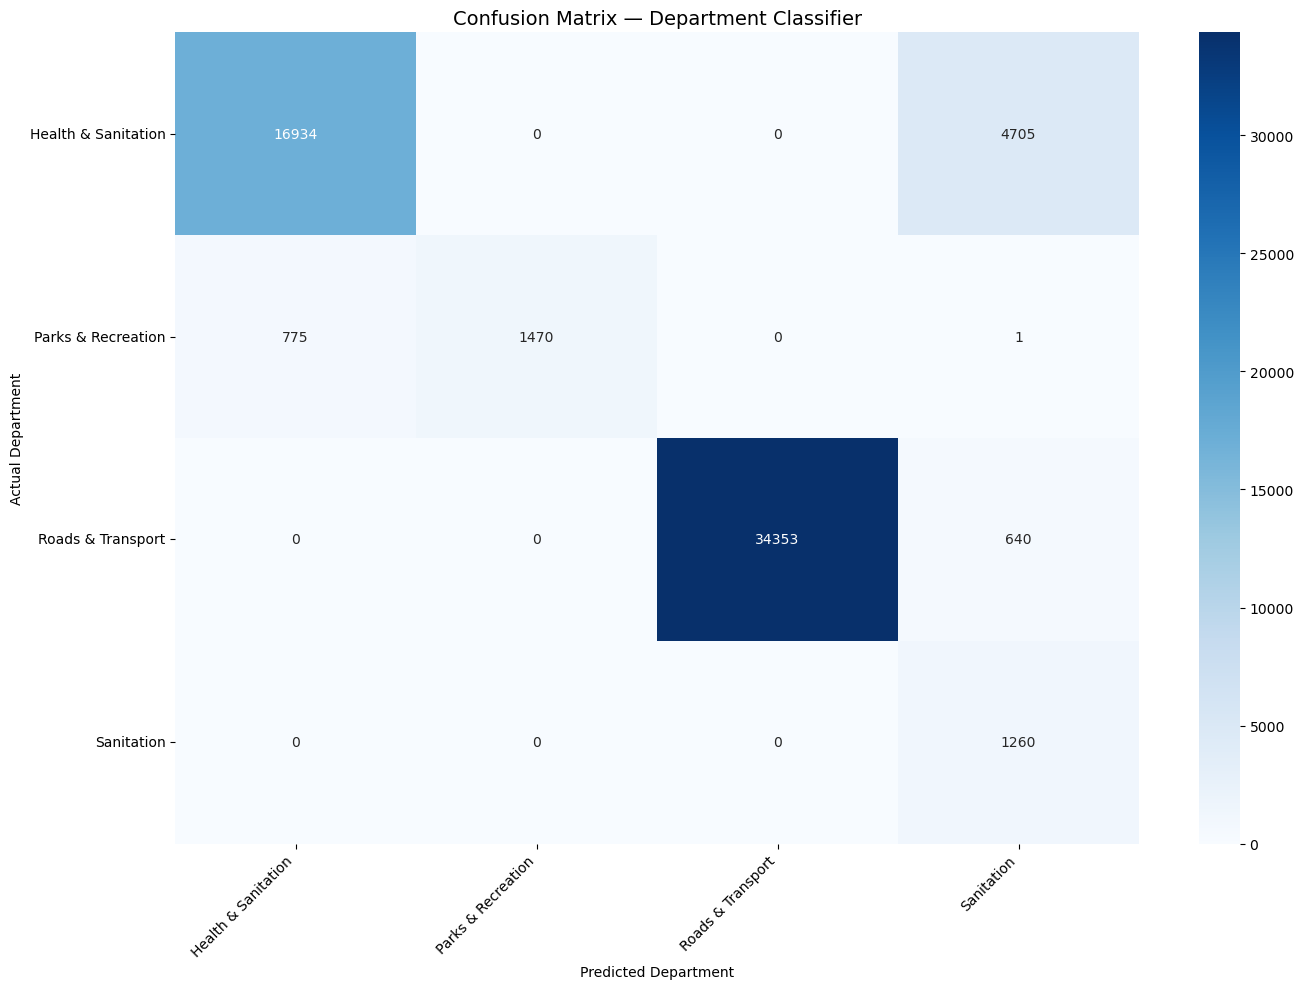

Saved as confusion_matrix.png


In [24]:
# Get unique labels
labels = sorted(y.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Department Classifier", fontsize=14)
plt.ylabel("Actual Department")
plt.xlabel("Predicted Department")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as confusion_matrix.png")

## Summary

| Metric | Value |
|--------|-------|
| Test set size | 60,138 rows |
| Overall Accuracy | 0.90 |
| Best performing department |  Roads & Transport |
| Weakest performing department | Sanitation |

The confusion matrix shows the model performs well on departments with 
large training samples. Smaller departments show lower recall due to 
class imbalance in the dataset.